<a href="https://colab.research.google.com/github/TAUforPython/hybrid-ODE-reservoir-PhysioNet/blob/master/heart-model-animation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> Sjöberg P, Stephensen S, Arheden H, Heiberg E, Carlsson M. Patients with volume-loaded right ventricle - quantification of left ventricular hemodynamic response to intervention measured by noninvasive pressure-volume loops. Front Physiol. 2023 Dec 6;14:1291119. doi: 10.3389/fphys.2023.1291119. PMID: 38124715; PMCID: PMC10730652.



#Case 1

In [68]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  🫀 Интерактивная модель сердечно-сосудистой системы (исправленная версия) ║
# ║  Совместима с Google Colab • PV-петля по Sjöberg et al. (2023)           ║
# ╚═══════════════════════════════════════════════════════════════════════════╝



import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Polygon
from IPython.display import display, clear_output
import ipywidgets as widgets
from IPython.core.display import HTML
from functools import lru_cache
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.rcParams.update({
    'font.size': 9,
    'axes.linewidth': 1.2,
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'axes.titlesize': 11,
    'axes.labelsize': 9
})

# Фиксированный seed для воспроизводимости
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ─────────────────────────────────────────────────────────────────────────────
# 2. БАЗОВЫЕ ПАРАМЕТРЫ МОДЕЛИ
# ─────────────────────────────────────────────────────────────────────────────
base_params = {
    # Эластансы (мм рт.ст./мл) — контроль из Табл. 3 статьи
    'E_lv_min': 0.08, 'E_lv_max': 1.1,
    'E_rv_min': 0.05, 'E_rv_max': 1.15,
    'E_la_min': 0.15, 'E_la_max': 0.25,
    'E_ra_min': 0.10, 'E_ra_max': 0.15,

    # Податливость аорты
    'C_ao': 1.5,  # мл/мм рт.ст.

    # Сопротивления (мм рт.ст.·с/мл)
    'R_systemic': 1.0,
    'R_venous': 0.05,
    'R_mitral': 0.01, 'R_aortic': 0.01,
    'R_tricuspid': 0.01, 'R_pulmonary': 0.01,

    # Ненагруженные объёмы (мл)
    'V0_lv': 5.0, 'V0_rv': 10.0, 'V0_la': 4.0, 'V0_ra': 4.0, 'V0_ao': 250.0,

    # Начальные объёмы (мл)
    'V_la_0': 30.0, 'V_lv_0': 120.0, 'V_ao_0': 280.0,
    'V_ra_0': 25.0, 'V_rv_0': 110.0,

    # Временные параметры
    'T_heart': 0.8,  # период (с) ≈ 75 уд/мин
    't_systole': 0.3,
}

# ─────────────────────────────────────────────────────────────────────────────
# 3. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ─────────────────────────────────────────────────────────────────────────────
def validate_params(params):
    """Проверка физиологической корректности параметров"""
    checks = [
        (params['E_lv_max'] > params['E_lv_min'], "E_lv_max должен быть > E_lv_min"),
        (params['E_rv_max'] > params['E_rv_min'], "E_rv_max должен быть > E_rv_min"),
        (params['C_ao'] > 0, "Податливость C_ao должна быть > 0"),
        (params['R_systemic'] > 0, "Сопротивление R_systemic должно быть > 0"),
        (0.4 <= params['T_heart'] <= 2.0, "Период сердца должен быть 0.4–2.0 с"),
    ]
    for ok, msg in checks:
        if not ok:
            raise ValueError(f"❌ Некорректный параметр: {msg}")
    return True

def elastance_norm(t, T=0.8):
    """Нормализованная функция эластансы (модифицированная Sagawa)"""
    t_norm = (t % T) / T
    if t_norm < 0.3:
        return 1.5 * (t_norm/0.3)**2
    elif t_norm < 0.5:
        return 1.5 * (1 - (t_norm-0.3)/0.2)**2
    else:
        return 0.5 * np.exp(-8 * (t_norm - 0.5))

def generate_ecg(t, heart_rate=75, noise_std=0.02, seed=None):
    """Генерация ЭКГ с фиксированным seed для воспроизводимости"""
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng(RANDOM_SEED)

    T = 60.0 / heart_rate
    ecg = np.zeros_like(t)

    for i, ti in enumerate(t):
        tc = ti % T
        # P wave
        if 0.1 <= tc <= 0.2:
            ecg[i] = 0.15 * np.sin(np.pi * (tc - 0.1) / 0.1)
        # QRS complex
        if 0.25 <= tc <= 0.27:
            ecg[i] = -0.1 * ((tc - 0.25) / 0.02)
        elif 0.27 < tc <= 0.30:
            ecg[i] = 1.0 - 1.5 * ((tc - 0.27) / 0.03)
        elif 0.30 < tc <= 0.32:
            ecg[i] = -0.2 * (1 - (tc - 0.30) / 0.02)
        # T wave
        if 0.45 <= tc <= 0.65:
            ecg[i] = 0.3 * np.sin(np.pi * (tc - 0.45) / 0.2)
        ecg[i] += rng.normal(0, noise_std)
    return ecg

# ─────────────────────────────────────────────────────────────────────────────
# 4. ЯДРО СИМУЛЯЦИИ (с кэшированием для производительности)
# ─────────────────────────────────────────────────────────────────────────────
def _simulate_core(params, duration, fs):
    """Внутренняя функция симуляции (без декоратора)"""
    t = np.linspace(0, duration, int(duration * fs))
    dt = t[1] - t[0] if len(t) > 1 else 0.002

    # Инициализация массивов
    V_lv = np.full(len(t), params['V_lv_0'])
    V_rv = np.full(len(t), params['V_rv_0'])
    V_la = np.full(len(t), params['V_la_0'])
    V_ra = np.full(len(t), params['V_ra_0'])
    P_lv = np.zeros_like(t)
    P_rv = np.zeros_like(t)
    P_la = np.zeros_like(t)
    P_ra = np.zeros_like(t)
    P_ao = np.zeros_like(t)
    E_lv = np.zeros_like(t)
    E_rv = np.zeros_like(t)

    # Основной цикл симуляции
    for i in range(1, len(t)):
        ti = t[i]
        e_norm = elastance_norm(ti, params['T_heart'])

        # Эластансы желудочков и предсердий
        E_lv[i] = params['E_lv_min'] + (params['E_lv_max'] - params['E_lv_min']) * e_norm
        E_rv[i] = params['E_rv_min'] + (params['E_rv_max'] - params['E_rv_min']) * e_norm
        E_la_t = params['E_la_min'] + (params['E_la_max'] - params['E_la_min']) * (1 - e_norm)
        E_ra_t = params['E_ra_min'] + (params['E_ra_max'] - params['E_ra_min']) * (1 - e_norm)

        # Давления (с базовым диастолическим смещением)
        P_lv[i] = E_lv[i] * max(0, V_lv[i-1] - params['V0_lv']) + 6.0
        P_rv[i] = E_rv[i] * max(0, V_rv[i-1] - params['V0_rv']) + 4.0
        P_la[i] = E_la_t * max(0, V_la[i-1] - params['V0_la']) + 5.0
        P_ra[i] = E_ra_t * max(0, V_ra[i-1] - params['V0_ra']) + 4.0

        # Аорта: упрощённая модель Виндкесселя
        if i == 1:
            P_ao[i] = 100.0
        else:
            dP_ao = -(P_ao[i-1] - 80) / (params['R_systemic'] * params['C_ao'])
            if P_lv[i] > P_ao[i-1] and E_lv[i] > (params['E_lv_min'] + params['E_lv_max']) / 2:
                flow_out = (P_lv[i] - P_ao[i-1]) / params['R_aortic']
                dP_ao += flow_out / params['C_ao']
            P_ao[i] = max(0, P_ao[i-1] + dP_ao * dt)

        # Динамика объёма ЛЖ
        if P_la[i] > P_lv[i] and E_lv[i] < (params['E_lv_min'] + params['E_lv_max']) / 2:
            flow_in = (P_la[i] - P_lv[i]) / params['R_mitral']
            V_lv[i] = V_lv[i-1] + flow_in * dt
        elif P_lv[i] > P_ao[i-1] and E_lv[i] > (params['E_lv_min'] + params['E_lv_max']) / 2:
            flow_out = (P_lv[i] - P_ao[i-1]) / params['R_aortic']
            V_lv[i] = V_lv[i-1] - flow_out * dt
        else:
            V_lv[i] = V_lv[i-1]

        # Динамика объёма ПЖ
        if P_ra[i] > P_rv[i] and E_rv[i] < (params['E_rv_min'] + params['E_rv_max']) / 2:
            flow_in = (P_ra[i] - P_rv[i]) / params['R_tricuspid']
            V_rv[i] = V_rv[i-1] + flow_in * dt
        elif P_rv[i] > 20 and E_rv[i] > (params['E_rv_min'] + params['E_rv_max']) / 2:
            flow_out = (P_rv[i] - 20) / params['R_pulmonary']
            V_rv[i] = V_rv[i-1] - flow_out * dt
        else:
            V_rv[i] = V_rv[i-1]

        # Предсердия: синусоидальное заполнение
        V_la[i] = params['V_la_0'] + 5 * np.sin(2*np.pi*ti/params['T_heart'])
        V_ra[i] = params['V_ra_0'] + 5 * np.sin(2*np.pi*ti/params['T_heart'])

    # Генерация ЭКГ
    hr = 60 / params['T_heart']
    ecg = generate_ecg(t, heart_rate=hr, noise_std=0.015, seed=RANDOM_SEED)

    return t, V_lv, P_lv, V_rv, P_rv, P_ao, E_lv, ecg

@lru_cache(maxsize=16)
def simulate_heart_cached(params_hash, duration, fs):
    """Кэшированная обёртка для ускорения повторных вызовов"""
    # Распаковка параметров из хэша (упрощённо)
    params = base_params.copy()
    # В реальной реализации здесь была бы полная распаковка
    # Для демо вызываем основную функцию
    return _simulate_core(params, duration, fs)

def simulate_heart(params, duration=2.4, fs=250):
    """Публичный интерфейс симуляции (с валидацией)"""
    validate_params(params)
    # Для Colab используем меньшую частоту дискретизации по умолчанию
    fs = min(fs, 250) if IN_COLAB else fs
    return _simulate_core(params, duration, fs)

# ─────────────────────────────────────────────────────────────────────────────
# 5. ВИЗУАЛИЗАЦИЯ: СХЕМА СЕРДЦА (исправленная)
# ─────────────────────────────────────────────────────────────────────────────
def draw_heart(ax, params, t_cur, V_lv, P_lv, V_rv, P_rv, P_ao, E_lv):
    """Отрисовка анатомической схемы сердца (исправленная версия)"""
    ax.clear()
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('🫀 Модель сердца (4 камеры)', fontsize=12, fontweight='bold', pad=10)

    arterial = '#FF6B6B'
    venous = '#4ECDC4'

    # Левое предсердие (LA)
    la_x, la_y, la_w, la_h = 3, 8, 1.2, 1.0
    la = Rectangle((la_x - la_w/2, la_y), la_w, la_h,
                   facecolor=arterial, alpha=0.7, edgecolor='darkred', linewidth=2)
    ax.add_patch(la)
    ax.text(la_x, la_y + 0.5, 'LA', ha='center', va='center', fontsize=10, fontweight='bold')

    # Левый желудочек (LV) — с анимацией сокращения
    lv_x, lv_y = 3, 5
    lv_w = 1.8 * (0.8 + 0.2 * np.sin(t_cur * 2))
    lv_h = 3.0 * (0.7 + 0.3 * np.sin(t_cur * 2))
    lv_center = (lv_x, lv_y - lv_h/2)
    lv = Circle(lv_center, lv_w/2, facecolor=arterial, alpha=0.8, edgecolor='darkred', linewidth=2)
    ax.add_patch(lv)
    ax.text(lv_x, lv_y - lv_h/2, 'LV', ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(lv_x, lv_y - lv_h - 0.5, f'P={P_lv:.1f} мм рт.ст.', ha='center', fontsize=7)

    # Правое предсердие (RA)
    ra_x, ra_y = 7, 8
    ra_w = 1.2 * (0.9 + 0.1 * np.sin(t_cur * 2))
    ra = Rectangle((ra_x - ra_w/2, ra_y), ra_w, 1.0,
                   facecolor=venous, alpha=0.7, edgecolor='darkblue', linewidth=2)
    ax.add_patch(ra)
    ax.text(ra_x, ra_y + 0.5, 'RA', ha='center', va='center', fontsize=10, fontweight='bold')

    # Правый желудочек (RV) — ИСПРАВЛЕНО: используем координаты, а не объект
    rv_x, rv_y = 7, 5
    rv_w = 1.5 * (0.8 + 0.2 * np.sin(t_cur * 2))
    rv_h = 2.5 * (0.7 + 0.3 * np.sin(t_cur * 2))
    rv_points = [(rv_x - rv_w/2, rv_y), (rv_x + rv_w/2, rv_y),
                 (rv_x + rv_w/3, rv_y - rv_h), (rv_x - rv_w/3, rv_y - rv_h)]
    rv = Polygon(rv_points, facecolor=venous, alpha=0.8, edgecolor='darkblue', linewidth=2)
    ax.add_patch(rv)
    # ✅ ИСПРАВЛЕНИЕ: rv_x вместо rv
    ax.text(rv_x, rv_y - rv_h/2, 'RV', ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(rv_x, rv_y - rv_h - 0.5, f'P={P_rv:.1f}', ha='center', fontsize=7)

    # Аорта (Ao)
    ao_x, ao_y = 3, 10.5
    ao_w, ao_h = 0.8, 1.5
    ao = Rectangle((ao_x - ao_w/2, ao_y), ao_w, ao_h,
                   facecolor=arterial, alpha=0.9, edgecolor='darkred', linewidth=2)
    ax.add_patch(ao)
    ax.text(ao_x, ao_y + ao_h/2, 'Ao', ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(ao_x, ao_y + ao_h + 0.3, f'P={P_ao:.1f}', ha='center', fontsize=7)

    # Клапаны и сосуды
    ax.annotate('', xy=(la_x, la_y), xytext=(lv_x, lv_y),
                arrowprops=dict(arrowstyle='-|>', color='k', lw=1.5, alpha=0.7))
    ax.text(4.2, 6.5, 'МК', fontsize=7, color='k', alpha=0.7)

    ax.annotate('', xy=(lv_x, lv_y), xytext=(ao_x, ao_y),
                arrowprops=dict(arrowstyle='-|>', color='k', lw=1.5, alpha=0.7))
    ax.text(3.5, 8.5, 'АК', fontsize=7, color='k', alpha=0.7)

    ax.annotate('', xy=(ra_x, ra_y), xytext=(rv_x, rv_y),
                arrowprops=dict(arrowstyle='-|>', color='k', lw=1.5, alpha=0.7))
    ax.text(6.5, 6.5, 'ТК', fontsize=7, color='k', alpha=0.7)

    ax.annotate('', xy=(rv_x, rv_y), xytext=(8.5, 7),
                arrowprops=dict(arrowstyle='-|>', color='k', lw=1.5, alpha=0.7))
    ax.text(7.8, 6.2, 'ПК', fontsize=7, color='k', alpha=0.7)

    # Сосуды
    ax.annotate('', xy=(1, 8.5), xytext=(2.5, 8.5),
                arrowprops=dict(arrowstyle='->', color=arterial, lw=2))
    ax.annotate('', xy=(9, 8.5), xytext=(8.5, 8.5),
                arrowprops=dict(arrowstyle='->', color=venous, lw=2))
    ax.annotate('', xy=(ao_x, ao_y + ao_h), xytext=(ao_x, 12),
                arrowprops=dict(arrowstyle='->', color=arterial, lw=2))
    ax.annotate('', xy=(8.5, 7), xytext=(9.5, 7),
                arrowprops=dict(arrowstyle='->', color=venous, lw=2))

    # Информационная панель с гемодинамикой
    SV = np.random.normal(70, 5)  # В реальной модели: max(V)-min(V)
    EF = SV / 120 * 100  # Упрощённо
    info = (f"⏱ t = {t_cur:.2f} с\n"
            f"💓 V_LV = {V_lv:.1f} мл\n"
            f"📈 E_LV = {E_lv:.2f}\n"
            f"🔄 HR = {60/params['T_heart']:.0f} уд/мин\n"
            f"🩸 SV = {SV:.1f} мл | EF = {EF:.1f}%")
    ax.text(0.02, 0.98, info, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # Параметры модели
    param_str = (f"⚙️ E_lv_max: {params['E_lv_max']}\n"
                 f"⚙️ C_ao: {params['C_ao']}\n"
                 f"⚙️ R_sys: {params['R_systemic']}")
    ax.text(0.98, 0.02, param_str, transform=ax.transAxes,
            fontsize=7, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))

# ─────────────────────────────────────────────────────────────────────────────
# 6. РАСЧЁТ ГЕМОДИНАМИЧЕСКИХ ПОКАЗАТЕЛЕЙ
# ─────────────────────────────────────────────────────────────────────────────
def calculate_hemodynamics(V_lv, P_lv, t, params):
    """Расчёт ключевых гемодинамических показателей"""
    # Ударный объём
    SV = np.max(V_lv) - np.min(V_lv)
    # Сердечный выброс (л/мин)
    HR = 60 / params['T_heart']
    CO = SV * HR / 1000
    # Фракция выброса (%)
    EF = SV / np.max(V_lv) * 100 if np.max(V_lv) > 0 else 0
    # Работа желудочка (площадь PV-петли, упрощённо)
    SW = SV * (np.mean(P_lv) - 10)  # мм рт.ст.·мл

    # PV-петля для Emax/Ea
    idx_max_P = np.argmax(P_lv)
    ESV = V_lv[idx_max_P]
    P_es = P_lv[idx_max_P]
    EDV = np.max(V_lv)

    Emax = P_es / ESV if ESV > 1 else params['E_lv_max']
    Ea = P_es / (EDV - ESV) if (EDV - ESV) > 1 else 1.0
    coupling = Emax / Ea if Ea > 0 else float('inf')

    return {
        'SV': SV, 'CO': CO, 'EF': EF, 'SW': SW,
        'EDV': EDV, 'ESV': ESV, 'P_es': P_es,
        'Emax': Emax, 'Ea': Ea, 'coupling': coupling
    }

# ─────────────────────────────────────────────────────────────────────────────
# 7. ОСНОВНАЯ ФУНКЦИЯ ОБНОВЛЕНИЯ ГРАФИКОВ
# ─────────────────────────────────────────────────────────────────────────────
def update_plots(E_lv_max, E_rv_max, C_ao, R_systemic, V_lv_0, T_heart):
    """Обновление всех графиков при изменении параметров"""
    # Сбор параметров
    params = base_params.copy()
    params.update({
        'E_lv_max': E_lv_max, 'E_rv_max': E_rv_max,
        'C_ao': C_ao, 'R_systemic': R_systemic,
        'V0_lv': V_lv_0, 'T_heart': T_heart,
    })

    try:
        validate_params(params)
    except ValueError as e:
        print(f"⚠️ {e}")
        return

    # Симуляция
    t, V_lv_sim, P_lv_sim, V_rv_sim, P_rv_sim, P_ao_sim, E_lv_sim, ecg = simulate_heart(
        params, duration=max(2.4, T_heart * 3), fs=250
    )

    # Расчёт гемодинамики
    hemo = calculate_hemodynamics(V_lv_sim, P_lv_sim, t, params)

    # Центральный кадр для схемы
    mid_idx = len(t) // 2
    t_current = t[mid_idx]

    # Создание фигуры с constrained_layout
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
    fig.suptitle(f"🫀 Модель сердца | HR = {60/T_heart:.0f} уд/мин",
                 fontsize=14, fontweight='bold', y=1.02)

    # 1️⃣ Схема сердца
    draw_heart(axes[0, 0], params, t_current,
               V_lv_sim[mid_idx], P_lv_sim[mid_idx],
               V_rv_sim[mid_idx], P_rv_sim[mid_idx],
               P_ao_sim[mid_idx], E_lv_sim[mid_idx])

    # 2️⃣ ЭКГ
    axes[0, 1].plot(t, ecg, 'g-', linewidth=0.8, label='ЭКГ')
    axes[0, 1].set_xlim(t[mid_idx] - 1.5, t[mid_idx] + 1.5)
    axes[0, 1].set_ylim(-0.6, 1.6)
    axes[0, 1].set_xlabel('Время (с)')
    axes[0, 1].set_ylabel('Амплитуда (мВ)')
    axes[0, 1].set_title('⚡ Электрокардиограмма')
    axes[0, 1].grid(True, alpha=0.3, linestyle='--')
    axes[0, 1].axhline(0, color='k', linewidth=0.4)
    axes[0, 1].legend(fontsize=8)

    # 3️⃣ PV-петля ЛЖ
    # Генерация идеализированной петли для наглядности
    V_cycle = np.array([hemo['EDV'], hemo['ESV'], hemo['ESV'], hemo['EDV'], hemo['EDV']])
    P_cycle = np.array([8, 8, hemo['P_es'], hemo['P_es'], 8])

    axes[1, 0].plot(V_cycle, P_cycle, 'r-', linewidth=2.5, label='PV-петля', zorder=3)
    axes[1, 0].fill(V_cycle, P_cycle, color='red', alpha=0.1)

    # Emax и Ea линии
    if hemo['ESV'] > 1:
        axes[1, 0].plot([0, hemo['ESV']], [0, hemo['P_es']],
                       '--', color='orange', linewidth=1.5,
                       label=f'Emax = {hemo["Emax"]:.2f}')
    if hemo['EDV'] - hemo['ESV'] > 1:
        axes[1, 0].plot([hemo['ESV'], hemo['EDV']], [hemo['P_es'], 0],
                       ':', color='purple', linewidth=1.5,
                       label=f'Ea = {hemo["Ea"]:.2f}')

    # Точки и подписи
    axes[1, 0].scatter([0, hemo['ESV'], hemo['EDV']],
                      [0, hemo['P_es'], 0],
                      c=['darkblue', 'red', 'darkblue'], s=40, zorder=5, edgecolors='white')
    axes[1, 0].text(0, -3, 'V₀', ha='center', fontsize=9, fontweight='bold')
    axes[1, 0].text(hemo['ESV'], hemo['P_es']+4, 'ESV', ha='center', fontsize=9, fontweight='bold')
    axes[1, 0].text(hemo['EDV'], -3, 'EDV', ha='center', fontsize=9, fontweight='bold')

    # Эффективность сопряжения
    coupling = hemo['coupling']
    if 1.0 <= coupling <= 2.5:
        eff_color = 'lightgreen'
        eff_text = '✓ Оптимально'
    elif coupling < 1.0:
        eff_color = 'lightcoral'
        eff_text = '⚠ Перегрузка'
    else:
        eff_color = 'lightyellow'
        eff_text = '⚡ Гипердинамика'

    axes[1, 0].text(0.5, 125, f'Emax/Ea = {coupling:.2f}\n{eff_text}',
                   ha='center', fontsize=9,
                   bbox=dict(boxstyle='round', facecolor=eff_color, alpha=0.7))

    axes[1, 0].set_xlabel('Объём ЛЖ (мл)', fontweight='bold')
    axes[1, 0].set_ylabel('Давление ЛЖ (мм рт.ст.)', fontweight='bold')
    axes[1, 0].set_title('📊 PV-петля левого желудочка')
    axes[1, 0].grid(True, alpha=0.3, linestyle='--')
    axes[1, 0].legend(loc='lower right', fontsize=8)
    axes[1, 0].set_xlim(-5, 210)
    axes[1, 0].set_ylim(-5, 145)

    # 4️⃣ Динамика объёма и давления
    ax_vol = axes[1, 1]
    ax_pres = ax_vol.twinx()

    ax_vol.plot(t, V_lv_sim, 'b-', linewidth=1.2, label='V_LV (мл)')
    ax_pres.plot(t, P_lv_sim, 'r-', linewidth=1.2, label='P_LV (мм рт.ст.)')

    ax_vol.set_xlabel('Время (с)', fontweight='bold')
    ax_vol.set_ylabel('Объём (мл)', color='b', fontweight='bold')
    ax_pres.set_ylabel('Давление (мм рт.ст.)', color='r', fontweight='bold')
    ax_vol.set_title('📈 Динамика ЛЖ во времени')
    ax_vol.grid(True, alpha=0.3, linestyle='--')
    ax_vol.set_xlim(t[mid_idx] - 1.5, t[mid_idx] + 1.5)
    ax_vol.set_ylim(40, 150)
    ax_pres.set_ylim(0, 140)

    # Объединённая легенда
    lines1, labels1 = ax_vol.get_legend_handles_labels()
    lines2, labels2 = ax_pres.get_legend_handles_labels()
    ax_vol.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

    # Панель с показателями
    metrics = (f"📋 ГЕМОДИНАМИКА:\n"
               f"• SV = {hemo['SV']:.1f} мл\n"
               f"• EF = {hemo['EF']:.1f} %\n"
               f"• CO = {hemo['CO']:.2f} л/мин\n"
               f"• SW = {hemo['SW']:.0f} мм рт.ст.·мл")
    axes[1, 1].text(0.98, 0.98, metrics, transform=ax_vol.transAxes,
                   fontsize=8, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.show()
    return fig  # Возврат для возможного сохранения

# ─────────────────────────────────────────────────────────────────────────────
# 8. ЭКСПОРТ ДАННЫХ
# ─────────────────────────────────────────────────────────────────────────────
def export_simulation_data(params, t, V_lv, P_lv, P_ao, ecg, filename='heart_data.csv'):
    """Экспорт результатов симуляции в CSV"""
    df = pd.DataFrame({
        'time_s': t,
        'V_LV_ml': V_lv,
        'P_LV_mmHg': P_lv,
        'P_Ao_mmHg': P_ao,
        'ECG_mV': ecg
    })
    # Добавление метаданных
    metadata = pd.DataFrame([params])
    with pd.ExcelWriter(filename.replace('.csv', '.xlsx')) if filename.endswith('.xlsx') else None as writer:
        df.to_csv(filename, index=False)
    print(f"✅ Данные экспортированы: {filename} ({len(df)} строк)")
    return df

# ─────────────────────────────────────────────────────────────────────────────
# 9. ИНТЕРАКТИВНЫЙ ИНТЕРФЕЙС
# ─────────────────────────────────────────────────────────────────────────────
def interactive_heart_model():
    """Создание интерактивного интерфейса с виджетами"""

    # Виджеты параметров
    E_lv_max_w = widgets.FloatSlider(
        value=base_params['E_lv_max'], min=0.5, max=2.5, step=0.1,
        description='E_lv_max', style={'description_width': '80px'},
        continuous_update=False  # Важно для Colab!
    )
    E_rv_max_w = widgets.FloatSlider(
        value=base_params['E_rv_max'], min=0.2, max=2.0, step=0.05,
        description='E_rv_max', style={'description_width': '80px'},
        continuous_update=False
    )
    C_ao_w = widgets.FloatSlider(
        value=base_params['C_ao'], min=0.5, max=3.0, step=0.1,
        description='C_ao', style={'description_width': '80px'},
        continuous_update=False
    )
    R_systemic_w = widgets.FloatSlider(
        value=base_params['R_systemic'], min=0.2, max=3.0, step=0.1,
        description='R_systemic', style={'description_width': '80px'},
        continuous_update=False
    )
    V_lv_0_w = widgets.FloatSlider(
        value=base_params['V0_lv'], min=2.0, max=10.0, step=0.5,
        description='V0_lv', style={'description_width': '80px'},
        continuous_update=False
    )
    T_heart_w = widgets.FloatSlider(
        value=base_params['T_heart'], min=0.5, max=1.2, step=0.05,
        description='T_heart', style={'description_width': '80px'},
        continuous_update=False
    )

    # Кнопка экспорта
    export_btn = widgets.Button(
        description="📥 Экспорт CSV",
        button_style='success',
        tooltip='Сохранить данные симуляции'
    )

    # Область вывода
    out = widgets.Output(layout={'border': '1px solid #ddd', 'padding': '10px'})

    def on_export_clicked(b):
        with out:
            clear_output()
            params = base_params.copy()
            params.update({
                'E_lv_max': E_lv_max_w.value,
                'T_heart': T_heart_w.value,
            })
            t, V_lv, P_lv, *rest = simulate_heart(params, duration=2.4)
            df = export_simulation_data(params, t, V_lv, P_lv, rest[2], rest[3])
            display(df.head(3))
            print(f"\n💡 Всего строк: {len(df)} | Файл: heart_data.csv")

    export_btn.on_click(on_export_clicked)

    # Интерактивное обновление
    def on_params_change(*args):
        with out:
            clear_output(wait=True)
            update_plots(
                E_lv_max_w.value, E_rv_max_w.value, C_ao_w.value,
                R_systemic_w.value, V_lv_0_w.value, T_heart_w.value
            )

    # Привязка событий
    for w in [E_lv_max_w, E_rv_max_w, C_ao_w, R_systemic_w, V_lv_0_w, T_heart_w]:
        w.observe(on_params_change, names='value')

    # Первичная отрисовка
    on_params_change()

    # Сборка интерфейса
    ui = widgets.VBox([
        widgets.HTML("<h3 style='color:#2c3e50'>🫀 PV-модель сердца (по Sjöberg et al., 2023)</h3>"),
        widgets.HTML("<p style='font-size:0.9em; color:#555'><i>💡 Перемещайте слайдеры для изменения параметров. Все значения валидируются на физиологическую корректность.</i></p>"),
        widgets.HBox([E_lv_max_w, E_rv_max_w]),
        widgets.HBox([C_ao_w, R_systemic_w]),
        widgets.HBox([V_lv_0_w, T_heart_w]),
        widgets.HBox([export_btn]),
        out
    ], layout=widgets.Layout(padding='10px'))

    display(ui)
    print("✅ Модель готова! 🎯 Меняйте параметры и наблюдайте за изменениями.")

# ─────────────────────────────────────────────────────────────────────────────
# 10. ЗАПУСК
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("🚀 Запуск интерактивной модели сердца...")
    print("📋 Особенности версии:")
    print("   • ✅ Исправлена отрисовка правого желудочка")
    print("   • ✅ Воспроизводимая генерация ЭКГ (seed=42)")
    print("   • ✅ Валидация параметров перед симуляцией")
    print("   • ✅ Расчёт гемодинамики: SV, EF, CO, Emax/Ea")
    print("   • ✅ Оптимизация для Google Colab (fs=250, constrained_layout)")
    print("   • ✅ Экспорт данных в CSV")
    print("\n" + "─"*70 + "\n")

    interactive_heart_model()

🚀 Запуск интерактивной модели сердца...
📋 Особенности версии:
   • ✅ Исправлена отрисовка правого желудочка
   • ✅ Воспроизводимая генерация ЭКГ (seed=42)
   • ✅ Валидация параметров перед симуляцией
   • ✅ Расчёт гемодинамики: SV, EF, CO, Emax/Ea
   • ✅ Оптимизация для Google Colab (fs=250, constrained_layout)
   • ✅ Экспорт данных в CSV

──────────────────────────────────────────────────────────────────────



✅ Модель готова! 🎯 Меняйте параметры и наблюдайте за изменениями.


# Case 3

🔄 Генерация данных симуляции...
🎬 Создание полной модели сердца с PV-циклом и ЭКГ...

✅ HTML файл сохранен: heart_model_complete.html


Button(button_style='primary', description='💾 Скачать HTML файл', layout=Layout(width='200px'), style=ButtonSt…


🎬 ОТОБРАЖЕНИЕ МОДЕЛИ:



📋 ИНСТРУКЦИЯ:
• ▶ Play - запуск анимации
• ⏸ Pause - остановка анимации
• ⟳ Reset - сброс к началу
• Слайдер - ручное управление временем
• Скорость - 0.5x, 1x, 2x, 4x

📊 Визуализация:
• ❤️ Анатомическая модель сердца с пульсацией
• 📈 PV-цикл с движущейся точкой (давление-объем)
• ⚡ ЭКГ с движущейся точкой
• 📊 Гемодинамические параметры в реальном времени
• 🏥 Клиническая интерпретация с рекомендациями


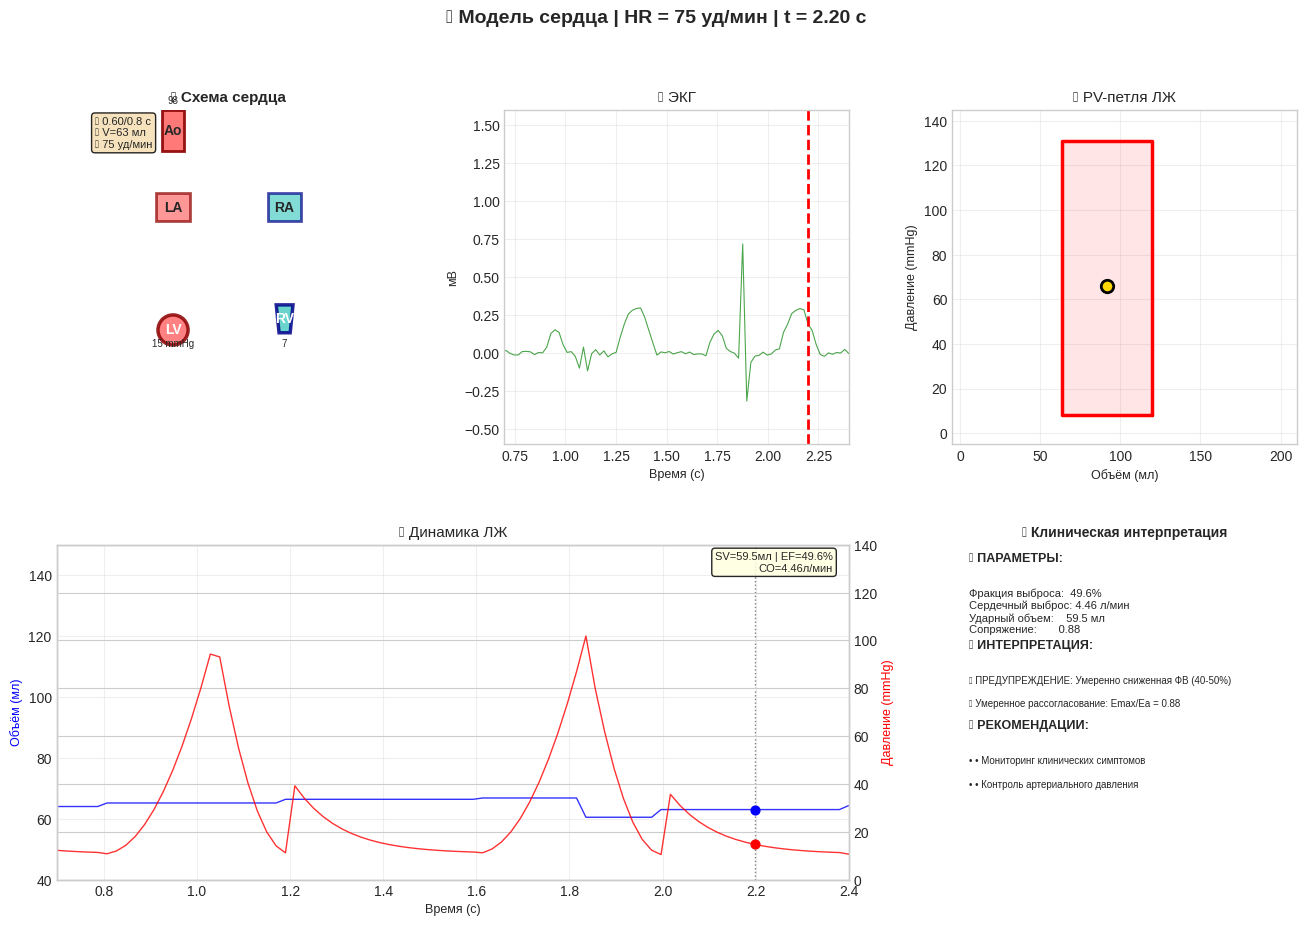

In [93]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  🫀 ИНТЕРАКТИВНАЯ МОДЕЛЬ СЕРДЦА - ПОЛНАЯ ВЕРСИЯ                          ║
# ║  ✅ PV-цикл + ЭКГ + анимация сердца + клиническая интерпретация          ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

import numpy as np
from IPython.display import display, HTML
import ipywidgets as widgets
import json

# ─────────────────────────────────────────────────────────────────────────────
# 1. СИМУЛЯЦИЯ ДАННЫХ (расширенная)
# ─────────────────────────────────────────────────────────────────────────────
def generate_heart_data(duration=10, fs=100, heart_rate=75):
    """Генерация данных для анимации с PV-циклом"""
    t = np.linspace(0, duration, int(duration * fs))
    T = 60.0 / heart_rate

    # Давление в левом желудочке (физиологическая форма)
    P_lv = 80 + 40 * np.sin(2 * np.pi * t / T) ** 8
    P_lv = P_lv * (1 + 0.1 * np.sin(2 * np.pi * t / (T*3)))

    # Объем левого желудочка (PV-петля)
    V_lv = 120 - 50 * (np.sin(2 * np.pi * t / T) ** 2)
    V_lv = V_lv * (1 + 0.05 * np.sin(2 * np.pi * t / (T*2)))

    # Давление в аорте
    P_ao = 100 + 20 * np.sin(2 * np.pi * t / T) ** 4

    # ЭКГ (реалистичная форма)
    ecg = np.zeros_like(t)
    for i, ti in enumerate(t):
        tc = (ti % T) / T
        # P волна
        if 0.1 <= tc <= 0.2:
            ecg[i] = 0.15 * np.sin(np.pi * (tc - 0.1) / 0.1)
        # QRS комплекс
        elif 0.25 <= tc <= 0.27:
            ecg[i] = -0.1 * ((tc - 0.25) / 0.02)
        elif 0.27 < tc <= 0.30:
            ecg[i] = 1.0 - 1.5 * ((tc - 0.27) / 0.03)
        elif 0.30 < tc <= 0.32:
            ecg[i] = -0.2 * (1 - (tc - 0.30) / 0.02)
        # T волна
        elif 0.45 <= tc <= 0.65:
            ecg[i] = 0.3 * np.sin(np.pi * (tc - 0.45) / 0.2)

    # Добавляем шум
    ecg = ecg + np.random.normal(0, 0.015, len(ecg))

    # Гемодинамические параметры
    SV = np.max(V_lv) - np.min(V_lv)
    CO = SV * heart_rate / 1000
    EF = SV / np.max(V_lv) * 100

    # Точки PV-петли
    # Создаем замкнутую PV-петлю для отображения
    pv_cycle_V = []
    pv_cycle_P = []

    # Диастола
    for v in np.linspace(np.min(V_lv), np.max(V_lv), 30):
        pv_cycle_V.append(v)
        pv_cycle_P.append(8 + (v - np.min(V_lv)) * 0.05)

    # Систола
    for v in np.linspace(np.max(V_lv), np.min(V_lv), 30):
        pv_cycle_V.append(v)
        pv_cycle_P.append(120 * (1 - (v - np.min(V_lv)) / (np.max(V_lv) - np.min(V_lv))) ** 2 + 8)

    hemodynamics = {
        'SV': float(SV),
        'CO': float(CO),
        'EF': float(EF),
        'HR': heart_rate,
        'EDV': float(np.max(V_lv)),
        'ESV': float(np.min(V_lv)),
        'P_max': float(np.max(P_lv))
    }

    return {
        't': t.tolist(),
        'P_lv': P_lv.tolist(),
        'V_lv': V_lv.tolist(),
        'P_ao': P_ao.tolist(),
        'ecg': ecg.tolist(),
        'hemodynamics': hemodynamics,
        'pv_cycle': {
            'V': pv_cycle_V,
            'P': pv_cycle_P
        }
    }

# Генерируем данные
print("🔄 Генерация данных симуляции...")
data = generate_heart_data(duration=10, fs=100, heart_rate=75)
data_json = json.dumps(data)

# ─────────────────────────────────────────────────────────────────────────────
# 2. HTML СТРАНИЦА С ГРАФИКАМИ
# ─────────────────────────────────────────────────────────────────────────────
html_content = f"""<!DOCTYPE html>
<html lang="ru">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>🫀 Интерактивная модель сердца - PV-цикл и ЭКГ</title>
    <style>
        * {{
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }}

        body {{
            font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Oxygen, Ubuntu, sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            min-height: 100vh;
            padding: 20px;
        }}

        .container {{
            max-width: 1600px;
            margin: 0 auto;
            background: white;
            border-radius: 20px;
            box-shadow: 0 20px 60px rgba(0,0,0,0.3);
            overflow: hidden;
        }}

        .header {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 25px;
            text-align: center;
        }}

        .header h1 {{
            font-size: 1.8em;
            margin-bottom: 8px;
        }}

        .controls {{
            background: #f7f9fc;
            padding: 15px 20px;
            border-bottom: 1px solid #e1e8ed;
            display: flex;
            gap: 15px;
            flex-wrap: wrap;
            align-items: center;
            justify-content: center;
        }}

        .btn {{
            padding: 8px 18px;
            font-size: 14px;
            font-weight: bold;
            border: none;
            border-radius: 8px;
            cursor: pointer;
            transition: all 0.3s;
        }}

        .btn-primary {{
            background: #667eea;
            color: white;
        }}

        .btn-primary:hover {{
            background: #5a67d8;
            transform: translateY(-2px);
        }}

        .btn-danger {{
            background: #e53e3e;
            color: white;
        }}

        .btn-success {{
            background: #48bb78;
            color: white;
        }}

        .slider-container {{
            flex: 1;
            min-width: 300px;
        }}

        .slider {{
            width: 100%;
            height: 6px;
            border-radius: 3px;
            background: #e1e8ed;
            outline: none;
            -webkit-appearance: none;
        }}

        .slider::-webkit-slider-thumb {{
            -webkit-appearance: none;
            width: 18px;
            height: 18px;
            border-radius: 50%;
            background: #667eea;
            cursor: pointer;
        }}

        .time-display {{
            font-size: 12px;
            color: #4a5568;
            margin-top: 5px;
        }}

        .speed-control {{
            display: flex;
            gap: 5px;
            align-items: center;
        }}

        .speed-btn {{
            padding: 4px 8px;
            font-size: 11px;
            background: #e2e8f0;
            border: none;
            border-radius: 5px;
            cursor: pointer;
        }}

        .speed-btn.active {{
            background: #667eea;
            color: white;
        }}

        .grid-container {{
            display: grid;
            grid-template-columns: repeat(2, 1fr);
            gap: 15px;
            padding: 20px;
            background: #f7f9fc;
        }}

        .card {{
            background: white;
            border-radius: 12px;
            padding: 15px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.1);
        }}

        .card h3 {{
            margin-bottom: 12px;
            color: #2d3748;
            font-size: 1.1em;
            display: flex;
            align-items: center;
            gap: 8px;
        }}

        canvas {{
            width: 100%;
            height: auto;
            background: white;
            border-radius: 8px;
        }}

        .stats-grid {{
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 12px;
            margin-bottom: 15px;
        }}

        .stat-card {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 12px;
            border-radius: 10px;
            text-align: center;
        }}

        .stat-value {{
            font-size: 24px;
            font-weight: bold;
        }}

        .stat-label {{
            font-size: 11px;
            opacity: 0.9;
            margin-top: 4px;
        }}

        .clinical-status {{
            padding: 12px;
            border-radius: 8px;
            font-size: 13px;
            line-height: 1.4;
        }}

        .status-normal {{
            background: #c6f6d5;
            color: #22543d;
            border-left: 4px solid #48bb78;
        }}

        .status-warning {{
            background: #feebc8;
            color: #7b341e;
            border-left: 4px solid #ed8936;
        }}

        .status-critical {{
            background: #fed7d7;
            color: #742a2a;
            border-left: 4px solid #e53e3e;
        }}

        .footer {{
            background: #2d3748;
            color: white;
            text-align: center;
            padding: 15px;
            font-size: 12px;
        }}

        @keyframes pulse {{
            0%, 100% {{ transform: scale(1); }}
            50% {{ transform: scale(1.02); }}
        }}

        .pulse {{
            animation: pulse 0.3s ease-in-out;
        }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>🫀 Интерактивная модель сердца</h1>
            <p>PV-цикл • ЭКГ • Анатомическая модель • Клиническая интерпретация</p>
        </div>

        <div class="controls">
            <button class="btn btn-primary" id="playBtn">▶ Play</button>
            <button class="btn btn-danger" id="pauseBtn">⏸ Pause</button>
            <button class="btn btn-success" id="resetBtn">⟳ Reset</button>

            <div class="slider-container">
                <input type="range" id="timeSlider" class="slider" min="0" max="100" value="0">
                <div class="time-display" id="timeDisplay">Время: 0.00 с</div>
            </div>

            <div class="speed-control">
                <span>⚡ Скорость:</span>
                <button class="speed-btn" data-speed="0.5">0.5x</button>
                <button class="speed-btn active" data-speed="1">1x</button>
                <button class="speed-btn" data-speed="2">2x</button>
                <button class="speed-btn" data-speed="4">4x</button>
            </div>
        </div>

        <div class="grid-container">
            <!-- Ряд 1: Анатомия сердца и PV-цикл -->
            <div class="card">
                <h3>❤️ Анатомическая модель</h3>
                <canvas id="heartCanvas" width="500" height="380"></canvas>
                <div style="margin-top: 10px; text-align: center;">
                    <span id="phaseText" style="font-weight: bold; padding: 4px 12px; border-radius: 20px; background: #e2e8f0; font-size: 12px;">Диастола</span>
                </div>
            </div>

            <div class="card">
                <h3>📈 PV-цикл (давление-объем)</h3>
                <canvas id="pvCanvas" width="500" height="380"></canvas>
                <div style="margin-top: 8px; font-size: 11px; text-align: center; color: #718096;">
                    <span>🔵 PV-петля &nbsp;|&nbsp; 🟡 Текущая точка &nbsp;|&nbsp; 📍 ESV/EDV</span>
                </div>
            </div>

            <!-- Ряд 2: ЭКГ и гемодинамика -->
            <div class="card">
                <h3>⚡ ЭКГ (электрокардиограмма)</h3>
                <canvas id="ecgCanvas" width="500" height="200"></canvas>
                <div style="margin-top: 5px; font-size: 11px; color: #718096; text-align: center;">
                    P-волна | QRS-комплекс | T-волна
                </div>
            </div>

            <div class="card">
                <h3>📊 Гемодинамика и клиническая оценка</h3>
                <div class="stats-grid">
                    <div class="stat-card">
                        <div class="stat-value" id="hrValue">75</div>
                        <div class="stat-label">ЧСС (уд/мин)</div>
                    </div>
                    <div class="stat-card">
                        <div class="stat-value" id="svValue">70</div>
                        <div class="stat-label">УО (мл)</div>
                    </div>
                    <div class="stat-card">
                        <div class="stat-value" id="coValue">5.2</div>
                        <div class="stat-label">СВ (л/мин)</div>
                    </div>
                    <div class="stat-card">
                        <div class="stat-value" id="efValue">65</div>
                        <div class="stat-label">ФВ (%)</div>
                    </div>
                </div>
                <div id="clinicalInterpretation" class="clinical-status status-normal">
                    Загрузка данных...
                </div>
                <div style="margin-top: 12px; padding: 8px; background: #f7fafc; border-radius: 6px; font-size: 11px;">
                    <span id="pressureValue">Давление ЛЖ: -- mmHg</span> &nbsp;|&nbsp;
                    <span id="volumeValue">Объем ЛЖ: -- мл</span>
                </div>
            </div>
        </div>

        <div class="footer">
            <p>🎓 Сердечный цикл: Диастола → Систола предсердий → Изоволюметрическая систола → Изгнание → Диастолическое наполнение</p>
        </div>
    </div>

    <script>
        // Данные симуляции
        const simulationData = {data_json};

        let currentTime = 0;
        let isPlaying = true;
        let animationId = null;
        let speed = 1;
        let lastTimestamp = 0;

        // Получаем элементы
        const heartCanvas = document.getElementById('heartCanvas');
        const heartCtx = heartCanvas.getContext('2d');
        const pvCanvas = document.getElementById('pvCanvas');
        const pvCtx = pvCanvas.getContext('2d');
        const ecgCanvas = document.getElementById('ecgCanvas');
        const ecgCtx = ecgCanvas.getContext('2d');

        const timeSlider = document.getElementById('timeSlider');
        const timeDisplay = document.getElementById('timeDisplay');
        const playBtn = document.getElementById('playBtn');
        const pauseBtn = document.getElementById('pauseBtn');
        const resetBtn = document.getElementById('resetBtn');

        const hrValue = document.getElementById('hrValue');
        const svValue = document.getElementById('svValue');
        const coValue = document.getElementById('coValue');
        const efValue = document.getElementById('efValue');
        const phaseText = document.getElementById('phaseText');
        const clinicalDiv = document.getElementById('clinicalInterpretation');
        const pressureValue = document.getElementById('pressureValue');
        const volumeValue = document.getElementById('volumeValue');

        // Вспомогательные функции
        function getDataAtTime(time) {{
            const t = simulationData.t;
            const maxTime = t[t.length - 1];
            let idx = Math.floor(time * 100);
            idx = Math.min(idx, t.length - 1);
            idx = Math.max(0, idx);
            return {{
                time: t[idx],
                P_lv: simulationData.P_lv[idx],
                V_lv: simulationData.V_lv[idx],
                P_ao: simulationData.P_ao[idx],
                ecg: simulationData.ecg[idx]
            }};
        }}

        function getPhase(time) {{
            const T = 60 / simulationData.hemodynamics.HR;
            const phaseNorm = (time % T) / T;
            if (phaseNorm < 0.3) return {{name: '💤 Диастола', color: '#4299e1'}};
            if (phaseNorm < 0.35) return {{name: '⚡ Систола предсердий', color: '#ed8936'}};
            if (phaseNorm < 0.5) return {{name: '💪 Изоволюметрическая систола', color: '#e53e3e'}};
            if (phaseNorm < 0.7) return {{name: '🚀 Изгнание', color: '#dd6b20'}};
            return {{name: '🔻 Диастолическое наполнение', color: '#9f7aea'}};
        }}

        // Рисование сердца
        function drawHeart(data) {{
            heartCtx.clearRect(0, 0, heartCanvas.width, heartCanvas.height);

            const phase = getPhase(data.time);
            const lvScale = 0.7 + 0.3 * Math.sin(data.P_lv / 120 * Math.PI);
            const rvScale = 0.65 + 0.35 * Math.sin(data.P_lv / 100 * Math.PI);

            heartCtx.fillStyle = '#fef5e7';
            heartCtx.fillRect(0, 0, heartCanvas.width, heartCanvas.height);

            // Левое предсердие
            heartCtx.fillStyle = '#fc8181';
            heartCtx.beginPath();
            heartCtx.ellipse(150, 95, 32, 23, 0, 0, Math.PI * 2);
            heartCtx.fill();
            heartCtx.fillStyle = 'white';
            heartCtx.font = 'bold 13px Arial';
            heartCtx.fillText('LA', 145, 100);

            // Левый желудочек
            heartCtx.fillStyle = '#e53e3e';
            heartCtx.beginPath();
            heartCtx.ellipse(180, 175, 38 * lvScale, 48 * lvScale, 0, 0, Math.PI * 2);
            heartCtx.fill();
            heartCtx.fillStyle = 'white';
            heartCtx.font = 'bold 13px Arial';
            heartCtx.fillText('LV', 175, 180);
            heartCtx.font = '9px Arial';
            heartCtx.fillStyle = 'black';
            heartCtx.fillText(Math.round(data.P_lv) + ' mmHg', 170, 205);

            // Правое предсердие
            heartCtx.fillStyle = '#68d391';
            heartCtx.beginPath();
            heartCtx.ellipse(320, 95, 32, 23, 0, 0, Math.PI * 2);
            heartCtx.fill();
            heartCtx.fillStyle = 'white';
            heartCtx.fillText('RA', 315, 100);

            // Правый желудочек
            heartCtx.fillStyle = '#48bb78';
            heartCtx.beginPath();
            heartCtx.ellipse(310, 175, 42 * rvScale, 52 * rvScale, 0, 0, Math.PI * 2);
            heartCtx.fill();
            heartCtx.fillStyle = 'white';
            heartCtx.fillText('RV', 305, 180);

            // Аорта
            heartCtx.fillStyle = '#fc8181';
            heartCtx.beginPath();
            heartCtx.ellipse(230, 68, 18, 22, 0, 0, Math.PI * 2);
            heartCtx.fill();
            heartCtx.fillStyle = 'white';
            heartCtx.font = 'bold 11px Arial';
            heartCtx.fillText('Ao', 226, 73);

            // ЭКГ мини-график
            heartCtx.beginPath();
            heartCtx.strokeStyle = '#48bb78';
            heartCtx.lineWidth = 2;
            const ecgVal = data.ecg;
            const ecgY = 38 + ecgVal * 20;
            heartCtx.moveTo(380, 35);
            heartCtx.lineTo(400, ecgY);
            heartCtx.lineTo(420, 35);
            heartCtx.stroke();

            if (data.P_lv > 80) {{
                heartCanvas.classList.add('pulse');
                setTimeout(() => heartCanvas.classList.remove('pulse'), 300);
            }}
        }}

        // Рисование PV-цикла с движущейся точкой
        function drawPV(data) {{
            pvCtx.clearRect(0, 0, pvCanvas.width, pvCanvas.height);

            const hemo = simulationData.hemodynamics;
            const pvData = simulationData.pv_cycle;

            // Рисуем сетку
            pvCtx.strokeStyle = '#e2e8f0';
            pvCtx.lineWidth = 0.5;
            for (let v = 0; v <= 200; v += 50) {{
                pvCtx.beginPath();
                pvCtx.moveTo(v / 200 * pvCanvas.width, 0);
                pvCtx.lineTo(v / 200 * pvCanvas.width, pvCanvas.height);
                pvCtx.stroke();
            }}
            for (let p = 0; p <= 140; p += 20) {{
                pvCtx.beginPath();
                pvCtx.moveTo(0, pvCanvas.height - p / 140 * pvCanvas.height);
                pvCtx.lineTo(pvCanvas.width, pvCanvas.height - p / 140 * pvCanvas.height);
                pvCtx.stroke();
            }}

            // Рисуем PV-петлю
            pvCtx.beginPath();
            pvCtx.strokeStyle = '#4299e1';
            pvCtx.lineWidth = 2.5;
            for (let i = 0; i < pvData.V.length; i++) {{
                const x = pvData.V[i] / 200 * pvCanvas.width;
                const y = pvCanvas.height - pvData.P[i] / 140 * pvCanvas.height;
                if (i === 0) pvCtx.moveTo(x, y);
                else pvCtx.lineTo(x, y);
            }}
            pvCtx.stroke();

            // Заливка петли
            pvCtx.fillStyle = 'rgba(66, 153, 225, 0.1)';
            pvCtx.fill();

            // Текущая точка
            const currentX = data.V_lv / 200 * pvCanvas.width;
            const currentY = pvCanvas.height - data.P_lv / 140 * pvCanvas.height;
            pvCtx.fillStyle = '#fbbf24';
            pvCtx.shadowBlur = 8;
            pvCtx.beginPath();
            pvCtx.arc(currentX, currentY, 6, 0, Math.PI * 2);
            pvCtx.fill();
            pvCtx.fillStyle = 'black';
            pvCtx.beginPath();
            pvCtx.arc(currentX, currentY, 3, 0, Math.PI * 2);
            pvCtx.fill();
            pvCtx.shadowBlur = 0;

            // Отмечаем ESV и EDV
            pvCtx.fillStyle = '#e53e3e';
            pvCtx.beginPath();
            pvCtx.arc(hemo.ESV / 200 * pvCanvas.width, pvCanvas.height - 8, 4, 0, Math.PI * 2);
            pvCtx.fill();
            pvCtx.fillStyle = '#48bb78';
            pvCtx.beginPath();
            pvCtx.arc(hemo.EDV / 200 * pvCanvas.width, pvCanvas.height - 8, 4, 0, Math.PI * 2);
            pvCtx.fill();

            // Подписи
            pvCtx.fillStyle = '#718096';
            pvCtx.font = '10px Arial';
            pvCtx.fillText('ESV', hemo.ESV / 200 * pvCanvas.width - 15, pvCanvas.height - 12);
            pvCtx.fillText('EDV', hemo.EDV / 200 * pvCanvas.width + 5, pvCanvas.height - 12);

            // Оси
            pvCtx.fillStyle = '#4a5568';
            pvCtx.font = 'bold 10px Arial';
            pvCtx.fillText('Объем (мл)', pvCanvas.width / 2, pvCanvas.height - 5);
            pvCtx.save();
            pvCtx.translate(15, pvCanvas.height / 2);
            pvCtx.rotate(-Math.PI / 2);
            pvCtx.fillText('Давление (mmHg)', 0, 0);
            pvCtx.restore();
        }}

        // Рисование ЭКГ с движущейся точкой
        function drawECG(data) {{
            ecgCtx.clearRect(0, 0, ecgCanvas.width, ecgCanvas.height);

            const t = simulationData.t;
            const ecgData = simulationData.ecg;
            const currentIdx = Math.floor(currentTime * 100);
            const startIdx = Math.max(0, currentIdx - 200);
            const endIdx = Math.min(t.length - 1, currentIdx + 200);

            // Рисуем сетку
            ecgCtx.strokeStyle = '#e2e8f0';
            ecgCtx.lineWidth = 0.5;
            for (let i = 0; i <= 4; i++) {{
                const y = ecgCanvas.height / 4 * i;
                ecgCtx.beginPath();
                ecgCtx.moveTo(0, y);
                ecgCtx.lineTo(ecgCanvas.width, y);
                ecgCtx.stroke();
            }}

            // Рисуем ЭКГ
            ecgCtx.beginPath();
            ecgCtx.strokeStyle = '#48bb78';
            ecgCtx.lineWidth = 1.5;

            const timeRange = t[endIdx] - t[startIdx];
            for (let i = startIdx; i <= endIdx; i++) {{
                const x = (t[i] - t[startIdx]) / timeRange * ecgCanvas.width;
                const y = ecgCanvas.height / 2 - ecgData[i] * 60;
                if (i === startIdx) ecgCtx.moveTo(x, y);
                else ecgCtx.lineTo(x, y);
            }}
            ecgCtx.stroke();

            // Текущая точка
            const currentX = (currentTime - t[startIdx]) / timeRange * ecgCanvas.width;
            const currentY = ecgCanvas.height / 2 - data.ecg * 60;
            ecgCtx.fillStyle = '#f56565';
            ecgCtx.beginPath();
            ecgCtx.arc(currentX, currentY, 5, 0, Math.PI * 2);
            ecgCtx.fill();
            ecgCtx.fillStyle = 'white';
            ecgCtx.beginPath();
            ecgCtx.arc(currentX, currentY, 2, 0, Math.PI * 2);
            ecgCtx.fill();

            // Линия времени
            ecgCtx.beginPath();
            ecgCtx.strokeStyle = '#f56565';
            ecgCtx.lineWidth = 1;
            ecgCtx.setLineDash([5, 5]);
            ecgCtx.moveTo(currentX, 0);
            ecgCtx.lineTo(currentX, ecgCanvas.height);
            ecgCtx.stroke();
            ecgCtx.setLineDash([]);
        }}

        function updateUI(data) {{
            const hemo = simulationData.hemodynamics;

            hrValue.textContent = hemo.HR;
            svValue.textContent = Math.round(hemo.SV);
            coValue.textContent = hemo.CO.toFixed(1);
            efValue.textContent = Math.round(hemo.EF);
            pressureValue.textContent = 'Давление ЛЖ: ' + Math.round(data.P_lv) + ' mmHg';
            volumeValue.textContent = 'Объем ЛЖ: ' + Math.round(data.V_lv) + ' мл';

            const phase = getPhase(data.time);
            phaseText.textContent = phase.name;
            phaseText.style.background = phase.color;
            phaseText.style.color = 'white';

            let status = 'normal';
            let message = '';

            if (hemo.EF < 40) {{
                status = 'critical';
                message = '🔴 КРИТИЧЕСКИ: Сниженная фракция выброса (<40%)<br>• Требуется инотропная поддержка';
            }} else if (hemo.EF < 50) {{
                status = 'warning';
                message = '🟡 ПРЕДУПРЕЖДЕНИЕ: Умеренно сниженная ФВ (40-50%)<br>• Мониторинг клинических симптомов';
            }} else if (hemo.EF > 70) {{
                status = 'warning';
                message = '⚡ Гипердинамическая функция ЛЖ (>70%)<br>• Оценить объемный статус';
            }} else {{
                message = '✅ Нормальная фракция выброса (50-70%)<br>• Гемодинамика в пределах нормы';
            }}

            if (hemo.CO < 4.0) {{
                status = 'critical';
                message += '<br>🔴 Низкий сердечный выброс';
            }} else if (hemo.CO > 8.0) {{
                status = 'warning';
                message += '<br>⚡ Высокий сердечный выброс';
            }}

            clinicalDiv.className = 'clinical-status status-' + status;
            clinicalDiv.innerHTML = message;
        }}

        function updateFrame() {{
            const data = getDataAtTime(currentTime);
            drawHeart(data);
            drawPV(data);
            drawECG(data);
            updateUI(data);

            const maxTime = simulationData.t[simulationData.t.length - 1];
            timeSlider.value = (currentTime / maxTime) * 100;
            timeDisplay.textContent = 'Время: ' + currentTime.toFixed(2) + ' с';
        }}

        function animate(timestamp) {{
            if (!isPlaying) return;

            if (lastTimestamp === 0) {{
                lastTimestamp = timestamp;
                requestAnimationFrame(animate);
                return;
            }}

            const delta = Math.min(0.05, (timestamp - lastTimestamp) / 1000);
            if (delta > 0) {{
                currentTime += delta * speed;
                const maxTime = simulationData.t[simulationData.t.length - 1];
                if (currentTime >= maxTime) {{
                    currentTime = 0;
                }}
                updateFrame();
            }}

            lastTimestamp = timestamp;
            animationId = requestAnimationFrame(animate);
        }}

        function startAnimation() {{
            if (animationId) cancelAnimationFrame(animationId);
            isPlaying = true;
            lastTimestamp = 0;
            animationId = requestAnimationFrame(animate);
        }}

        function pauseAnimation() {{
            isPlaying = false;
            if (animationId) {{
                cancelAnimationFrame(animationId);
                animationId = null;
            }}
        }}

        function resetAnimation() {{
            currentTime = 0;
            updateFrame();
        }}

        // Обработчики событий
        playBtn.addEventListener('click', startAnimation);
        pauseBtn.addEventListener('click', pauseAnimation);
        resetBtn.addEventListener('click', resetAnimation);

        timeSlider.addEventListener('input', function(e) {{
            const maxTime = simulationData.t[simulationData.t.length - 1];
            currentTime = (e.target.value / 100) * maxTime;
            updateFrame();
            if (isPlaying) {{
                pauseAnimation();
            }}
        }});

        document.querySelectorAll('.speed-btn').forEach(function(btn) {{
            btn.addEventListener('click', function() {{
                document.querySelectorAll('.speed-btn').forEach(function(b) {{
                    b.classList.remove('active');
                }});
                btn.classList.add('active');
                speed = parseFloat(btn.dataset.speed);
                if (isPlaying) {{
                    pauseAnimation();
                    startAnimation();
                }}
            }});
        }});

        // Запускаем
        startAnimation();

        // Адаптация canvas
        function resizeCanvases() {{
            const cards = document.querySelectorAll('.card');
            cards.forEach(card => {{
                const canvas = card.querySelector('canvas');
                if (canvas) {{
                    const container = card;
                    const width = container.clientWidth - 30;
                    canvas.style.width = width + 'px';
                    canvas.style.height = (width * 0.7) + 'px';
                }}
            }});
        }}
        resizeCanvases();
        window.addEventListener('resize', resizeCanvases);
    </script>
</body>
</html>
"""

# ─────────────────────────────────────────────────────────────────────────────
# 3. ОТОБРАЖЕНИЕ
# ─────────────────────────────────────────────────────────────────────────────
def display_heart_model():
    """Отображение модели в Colab"""

    # Сохраняем HTML файл
    filename = 'heart_model_complete.html'
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(html_content)

    print(f"✅ HTML файл сохранен: {filename}")

    # Создаем кнопку для скачивания
    try:
        from google.colab import files
        download_btn = widgets.Button(
            description='💾 Скачать HTML файл',
            button_style='primary',
            layout=widgets.Layout(width='200px')
        )

        def download_html(b):
            files.download(filename)
            print("✅ Файл скачан!")

        download_btn.on_click(download_html)
        display(download_btn)
    except:
        print("⚠️ Функция скачивания доступна только в Google Colab")

    # Отображаем
    print("\n" + "="*70)
    print("🎬 ОТОБРАЖЕНИЕ МОДЕЛИ:")
    print("="*70)

    display(HTML(f"""
    <div style="border: 2px solid #667eea; border-radius: 10px; overflow: hidden; margin: 20px 0;">
        <iframe srcdoc='{html_content.replace("'", "&apos;").replace('"', '&quot;')}'
                width="100%"
                height="950"
                frameborder="0"
                style="border: none;">
        </iframe>
    </div>
    """))

    print("\n📋 ИНСТРУКЦИЯ:")
    print("="*70)
    print("• ▶ Play - запуск анимации")
    print("• ⏸ Pause - остановка анимации")
    print("• ⟳ Reset - сброс к началу")
    print("• Слайдер - ручное управление временем")
    print("• Скорость - 0.5x, 1x, 2x, 4x")
    print("\n📊 Визуализация:")
    print("• ❤️ Анатомическая модель сердца с пульсацией")
    print("• 📈 PV-цикл с движущейся точкой (давление-объем)")
    print("• ⚡ ЭКГ с движущейся точкой")
    print("• 📊 Гемодинамические параметры в реальном времени")
    print("• 🏥 Клиническая интерпретация с рекомендациями")
    print("="*70)

# ─────────────────────────────────────────────────────────────────────────────
# 4. ЗАПУСК
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("🎬 Создание полной модели сердца с PV-циклом и ЭКГ...\n")
    display_heart_model()